In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from scipy.sparse import hstack, csr_matrix

In [2]:
BASE = Path(r"C:\docfusion_data\findit2")
PROJECT_ROOT = Path(r"C:\docfusion_project")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.findit_loader import load_findit_split

In [3]:
train_df = load_findit_split(BASE, "train")
val_df   = load_findit_split(BASE, "val")
test_df  = load_findit_split(BASE, "test")

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

train: (577, 5)
val:   (193, 5)
test:  (218, 5)


In [4]:
def join_lines(lines):
    if isinstance(lines, list):
        return "\n".join(lines)
    return ""

for df_ in [train_df, val_df, test_df]:
    df_["text"] = df_["lines"].apply(join_lines)
    df_["n_lines"] = df_["lines"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df_["n_chars"] = df_["text"].str.len()
    df_["n_words"] = df_["text"].str.split().apply(len)

In [5]:
amount_pattern = re.compile(r"\b\d+[.,]\d{2}\b")
date_pattern = re.compile(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b")
digit_pattern = re.compile(r"\d")


def build_manual_features(df):
    out = pd.DataFrame(index=df.index)

    out["n_lines"] = df["n_lines"]
    out["n_chars"] = df["n_chars"]
    out["n_words"] = df["n_words"]

    out["avg_line_len"] = np.where(df["n_lines"] > 0, df["n_chars"] / df["n_lines"], 0)
    out["avg_word_len"] = np.where(df["n_words"] > 0, df["n_chars"] / df["n_words"], 0)

    out["digit_count"] = df["text"].apply(lambda x: len(digit_pattern.findall(x)))
    out["amount_like_count"] = df["text"].apply(lambda x: len(amount_pattern.findall(x)))
    out["date_like_count"] = df["text"].apply(lambda x: len(date_pattern.findall(x)))

    out["has_total_word"] = df["text"].str.lower().str.contains(r"\btotal\b", regex=True).astype(int)
    out["has_tax_word"] = df["text"].str.lower().str.contains(r"\btax\b", regex=True).astype(int)
    out["has_invoice_word"] = df["text"].str.lower().str.contains(r"\binvoice\b", regex=True).astype(int)
    out["has_cash_word"] = df["text"].str.lower().str.contains(r"\bcash\b", regex=True).astype(int)
    out["has_change_word"] = df["text"].str.lower().str.contains(r"\bchange\b", regex=True).astype(int)
    out["has_subtotal_word"] = df["text"].str.lower().str.contains(r"\bsubtotal\b", regex=True).astype(int)

    out["empty_text"] = (df["n_chars"] == 0).astype(int)
    out["very_short_text"] = (df["n_words"] <= 3).astype(int)

    return out

In [6]:
X_train_manual = build_manual_features(train_df)
X_val_manual   = build_manual_features(val_df)
X_test_manual  = build_manual_features(test_df)

y_train = train_df["is_forged"].astype(int)
y_val   = val_df["is_forged"].astype(int)
y_test  = test_df["is_forged"].astype(int)

X_train_manual.head()

,n_lines,n_chars,n_words,avg_line_len,avg_word_len,digit_count,amount_like_count,date_like_count,has_total_word,has_tax_word,has_invoice_word,has_cash_word,has_change_word,has_subtotal_word,empty_text,very_short_text
0,60,584,105,9.733333,5.561905,124,14,1,1,1,1,1,1,0,0,0
1,61,797,144,13.065574,5.534722,214,15,1,1,0,1,1,1,0,0,0
2,47,664,111,14.127660,5.981982,110,8,1,1,1,1,0,0,0,0,0
3,41,576,94,14.048780,6.127660,107,7,1,1,0,1,1,0,0,0,0
4,93,916,157,9.849462,5.834395,265,32,1,1,1,0,1,1,0,0,0


In [7]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_features=3000
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_val_tfidf   = tfidf.transform(val_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

X_train = hstack([csr_matrix(X_train_manual.values), X_train_tfidf])
X_val   = hstack([csr_matrix(X_val_manual.values), X_val_tfidf])
X_test  = hstack([csr_matrix(X_test_manual.values), X_test_tfidf])

X_train.shape, X_val.shape, X_test.shape

((577, 3016), (193, 3016), (218, 3016))

In [8]:
def evaluate_model(name, model, X_tr, y_tr, X_va, y_va):
    model.fit(X_tr, y_tr)

    pred = model.predict(X_va)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_va)[:, 1]
    else:
        prob = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_va, pred),
        "precision": precision_score(y_va, pred, zero_division=0),
        "recall": recall_score(y_va, pred, zero_division=0),
        "f1": f1_score(y_va, pred, zero_division=0),
    }

    if prob is not None and len(np.unique(y_va)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_va, prob)
    else:
        metrics["roc_auc"] = np.nan

    print(f"\n{name}")
    print("-" * len(name))
    print(pd.Series(metrics))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_va, pred))
    print("\nClassification report:")
    print(classification_report(y_va, pred, zero_division=0))

    return model, metrics

In [9]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logreg, logreg_metrics = evaluate_model(
    "Logistic Regression",
    logreg,
    X_train, y_train,
    X_val, y_val
)


Logistic Regression
-------------------
model        Logistic Regression
accuracy                0.683938
precision                    0.2
recall                  0.264706
f1                      0.227848
roc_auc                 0.514243
dtype: object

Confusion matrix:
[[123  36]
 [ 25   9]]

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       159
           1       0.20      0.26      0.23        34

    accuracy                           0.68       193
   macro avg       0.52      0.52      0.51       193
weighted avg       0.72      0.68      0.70       193



c:\Users\Aminpatra\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf, rf_metrics = evaluate_model(
    "Random Forest (manual features only)",
    rf,
    X_train_manual, y_train,
    X_val_manual, y_val
)


Random Forest (manual features only)
------------------------------------
model        Random Forest (manual features only)
accuracy                                 0.797927
precision                                0.142857
recall                                   0.029412
f1                                        0.04878
roc_auc                                  0.511006
dtype: object

Confusion matrix:
[[153   6]
 [ 33   1]]

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.89       159
           1       0.14      0.03      0.05        34

    accuracy                           0.80       193
   macro avg       0.48      0.50      0.47       193
weighted avg       0.70      0.80      0.74       193



In [11]:
results = pd.DataFrame([logreg_metrics, rf_metrics]).sort_values("f1", ascending=False)
results

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.683938,0.200000,0.264706,0.227848,0.514243
1,Random Forest (manual features only),0.797927,0.142857,0.029412,0.048780,0.511006


In [12]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train_manual.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_feature_importance

,feature,importance
4,avg_word_len,0.155396
3,avg_line_len,0.154101
1,n_chars,0.149267
5,digit_count,0.137128
2,n_words,0.125537
0,n_lines,0.106448
6,amount_like_count,0.082851
7,date_like_count,0.024524
11,has_cash_word,0.014332
12,has_change_word,0.014001


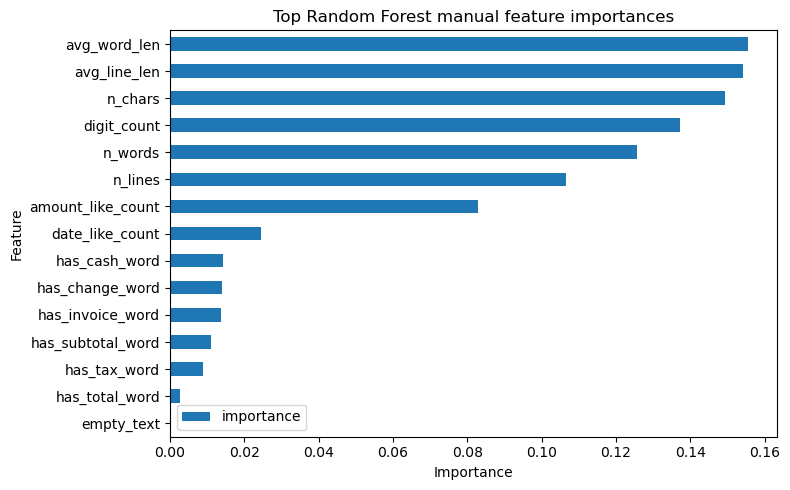

In [13]:
rf_feature_importance.head(15).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 5)
)

plt.title("Top Random Forest manual feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [14]:
manual_feature_names = list(X_train_manual.columns)
tfidf_feature_names = list(tfidf.get_feature_names_out())
all_feature_names = manual_feature_names + tfidf_feature_names

coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coef
}).sort_values("coef")

print("Most genuine-leaning features")
display(coef_df.head(20))

print("Most forged-leaning features")
display(coef_df.tail(20))

Most genuine-leaning features


,feature,coef
341,15,-0.700868
621,40,-0.681002
682,46,-0.668193
804,65,-0.647305
2351,rm 00,-0.572401
882,83,-0.556946
474,2018 18,-0.518041
1019,all,-0.495050
364,17,-0.486016
576,31,-0.479489


Most forged-leaning features


,feature,coef
206,07 2017,0.524205
618,390,0.525361
283,119,0.529728
614,39,0.557769
2952,vs,0.559960
2954,walk,0.562521
2436,rm9 00,0.580770
1127,batu,0.584689
2496,section,0.600862
1865,kapar,0.605810


In [15]:
best_model = logreg

test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

print("Test metrics")
print("------------")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall:", recall_score(y_test, test_pred, zero_division=0))
print("F1:", f1_score(y_test, test_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

Test metrics
------------
Accuracy: 0.7385321100917431
Precision: 0.25
Recall: 0.3142857142857143
F1: 0.27848101265822783
ROC-AUC: 0.5667447306791569

Confusion matrix:
[[150  33]
 [ 24  11]]


In [16]:
test_results = test_df[["id", "text", "is_forged"]].copy()
test_results["pred"] = test_pred
test_results["prob_forged"] = test_prob
test_results["correct"] = (test_results["is_forged"] == test_results["pred"])

test_results.head()

,id,text,is_forged,pred,prob_forged,correct
0,X00016469619,"TAN WOON YANN\nINDAH GIFT & HOME DECO\n27,JALA...",0,0,0.463022,True
1,X00016469620,TAN WOON YANN\nMR D.T.Y. (JOHOR) SDN BHD\n(CO....,0,0,0.461803,True
2,X00016469669,"TAN CHAY YEE\nABC HO TRADING\nNO.2&4,JALAN HAR...",0,0,0.342282,True
3,X00016469676,TAN CHAY YEE\nS.H.H. MOTOR (SUNGAI RENGIT) SDN...,0,0,0.484315,True
4,X51005230616,190\nGERBANG ALAF RESTAURANTS SDN BHD\n(65351-...,1,1,0.629954,True


In [17]:
false_negatives = test_results[(test_results["is_forged"] == 1) & (test_results["pred"] == 0)]
false_negatives[["id", "is_forged", "pred", "prob_forged"]].sort_values("prob_forged").head(10)

,id,is_forged,pred,prob_forged
83,X51006329183,1,0,0.221770
207,X51008123447,1,0,0.239762
202,X51008099081,1,0,0.260984
38,X51005605295,1,0,0.276537
211,X51008142038,1,0,0.301031
26,X51005447853,1,0,0.326883
118,X51006556603,1,0,0.330179
108,X51006414715,1,0,0.331344
98,X51006401977,1,0,0.332859
191,X51007846357,1,0,0.332879


In [18]:
false_positives = test_results[(test_results["is_forged"] == 0) & (test_results["pred"] == 1)]
false_positives[["id", "is_forged", "pred", "prob_forged"]].sort_values("prob_forged", ascending=False).head(10)

,id,is_forged,pred,prob_forged
23,X51005447842,0,1,0.791392
100,X51006414519,0,1,0.743400
114,X51006555570,0,1,0.733192
201,X51008099073,0,1,0.729968
110,X51006438346,0,1,0.729196
174,X51007339116,0,1,0.702954
175,X51007339118,0,1,0.641879
78,X51006008089,0,1,0.632087
19,X51005442366,0,1,0.619863
57,X51005712017,0,1,0.610800


In [19]:
for _, row in false_negatives.head(3).iterrows():
    print("=" * 100)
    print("FALSE NEGATIVE")
    print("ID:", row["id"])
    print("True:", row["is_forged"], "| Pred:", row["pred"], "| Prob:", round(row["prob_forged"], 4))
    print("-" * 100)
    print(row["text"][:2000])
    print()

for _, row in false_positives.head(3).iterrows():
    print("=" * 100)
    print("FALSE POSITIVE")
    print("ID:", row["id"])
    print("True:", row["is_forged"], "| Pred:", row["pred"], "| Prob:", round(row["prob_forged"], 4))
    print("-" * 100)
    print(row["text"][:2000])
    print()

FALSE NEGATIVE
ID: X51005442361
True: 1 | Pred: 0 | Prob: 0.4624
----------------------------------------------------------------------------------------------------
MORGANFIELD'S R
HORNG OF SDCKY BONES
TIME LESS KITCHENETTE SDN BHD
COMPANY NO : 1874723-K
GST REG NO : 0000 6771 0976
LOT 50, FLOOR T5,SKY AVENUE GENTING HIGHLANDS
PAHANG, 69000 PAHANG MALAYSLA
GUEST CHECK
INVOICE NO: 000039121
DATE: 2018-03-23
CASHIER : MIZAN GENTING SERVER :
OPEN: 18:43:34
TABLE: 25
PAX: 6
1
RIBS PLATTER
SR
259.90
1
NAUGHTY SPARE RIB - FULL
SR
106.90
SLAB
1
APPLE - 350ML
SR
13.90
1
SOUR APPLE MOJITO
SR
18.90
1
BERRY EASY
SR
18.90
1
AUST RIB-EYE STEAK
SR
74.90
1
FRUITY GARDEN SALAD
SR
21.90
2
HH ASAHI 1+1/2
SR
77.80
SUB-TOTAL :
593.10
(INCLUSIVE) GST 6%
33.57
TOTAL :
19:32:35
TOTAL:
593.10
GST SUMM
AMT (RM)
TAX(RM)
SR=
6%
559.53
33.57
OS=
0%
0.00
0

FALSE NEGATIVE
ID: X51005447853
True: 1 | Pred: 0 | Prob: 0.3269
---------------------------------------------------------------------------------------------

## Baseline Conclusion

- A lightweight forged-document classifier was built using OCR-derived features.
- Two baselines were compared:
  - Logistic Regression with manual + TF-IDF features
  - Random Forest with manual features
- The best baseline is suitable as the first anomaly-detection component for integration into the main DocFusion pipeline.
- Error analysis suggests that some forgeries are subtle and may require stronger visual or layout-based features later.

## Next step

Integrate the best anomaly baseline into the project codebase so that it can be used inside `solution.py`.